# Notebook 3: Census Data Integration with censusdis

**CCOM 6994: Data Analysis Tools - Final Project**  
**Course: Análisis de Datos de Paneles Solares**

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1.  **Discover Census Datasets**: Programmatically list available datasets and variables using the Census API.
2.  **Fetch Demographic Data**: Retrieve ACS 5-Year Estimates for the entire US and Puerto Rico.
3.  **Visualize Spatial Data**: Create choropleth maps to analyze income distribution.
4.  **Persist Data**: Save census data to DuckDB with proper identifiers (`GEOID`) for integration.

## 📚 References & Documentation

-   [censusdis Introduction](https://censusdis.readthedocs.io/en/latest/intro.html)
-   [Census API Datasets (2020)](https://api.census.gov/data/2020.html)
-   [Exploring Variables](https://censusdis.readthedocs.io/en/latest/nb/Exploring%20Variables.html)
-   [Data With Geometry](https://censusdis.readthedocs.io/en/latest/nb/Data%20With%20Geometry.html)

---

## 🔧 Setup: Import Libraries

In [1]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import duckdb
from dotenv import load_dotenv

# censusdis imports
import censusdis.data as ced
import censusdis.states as states

# Load environment variables
load_dotenv(dotenv_path=os.path.join(os.path.dirname(os.getcwd()), '.env'))

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


---

## 🔍 Part 1: Programmatic Data Discovery

Instead of hardcoding dataset names and variables, let's explore what's available via the Census API.

### 1.1 Listing Available Datasets (2020)

The Census API provides a list of datasets for each year. We can fetch this table directly.

In [2]:
YEAR = 2020
DATASETS_URL = f"https://api.census.gov/data/{YEAR}.html"

print(f"🔍 Fetching available datasets for {YEAR} from: {DATASETS_URL}")

try:
    # Read HTML tables from the URL
    tables = pd.read_html(DATASETS_URL)
    datasets_df = tables[0] # The first table usually contains the dataset list
    
    # Clean up the dataframe
    # The table structure varies, but usually has Title, Description, Dataset Name, etc.
    print(f"   Found {len(datasets_df)} datasets.")
    
    # Filter for ACS datasets as an example
    acs_datasets = datasets_df[datasets_df['Title'].astype(str).str.contains('American Community Survey', case=False, na=False)]
    print("\n📊 ACS Datasets found:")
    display(acs_datasets[['Title', 'Description']].head())
    
except Exception as e:
    print(f"⚠️ Could not fetch datasets programmatically: {e}")
    print("   Falling back to manual selection.")

🔍 Fetching available datasets for 2020 from: https://api.census.gov/data/2020.html
   Found 63 datasets.

📊 ACS Datasets found:


,Title,Description
6,American Community Survey: 5-Year Estimates: Detailed Tables 5-Year,The American Community Survey (ACS) is an ongoing survey that provides data every year -- giving...
7,American Community Survey: 5-Year Estimates: Comparison Profiles 5-Year,The American Community Survey (ACS) is an ongoing survey that provides data every year -- giving...
8,American Community Survey: 5-Year Estimates: Data Profiles 5-Year,The American Community Survey (ACS) is an ongoing survey that provides data every year -- giving...
9,2020 American Community Survey: 5-Year Estimates - Public Use Microdata Sample,The American Community Survey (ACS) Public Use Microdata Sample (PUMS) contains a sample of resp...
10,2020 American Community Survey: 5-Year Estimates - Public Use Microdata Sample Puerto Rico,The Public Use Microdata Sample (PUMS) for Puerto Rico (PR) contains a sample of responses to th...


In [3]:
# manageable with data wrangler extension in vscode
display(tables[0])

,Title,Description,Vintage,Dataset Name,Dataset Type,Geography List,Variable List,Group List,SortList,Examples,Developer Documentation,API Base URL
0,2020 Annual Business Survey: Characteristics of Business,The Annual Business Survey (ABS) provides information on selected economic and demographic chara...,2020,abscb,Aggregate,geographies,variables,groups,sorts,examples,documentation,http://api.census.gov/data/2020/abscb
1,2020 Annual Business Survey: Characteristics of Business Owners,The Annual Business Survey (ABS) provides information on selected economic and demographic chara...,2020,abscbo,Aggregate,geographies,variables,groups,sorts,examples,documentation,http://api.census.gov/data/2020/abscbo
2,2020 Annual Business Survey: Company Summary,The Annual Business Survey (ABS) provides information on selected economic and demographic chara...,2020,abscs,Aggregate,geographies,variables,groups,sorts,examples,documentation,http://api.census.gov/data/2020/abscs
3,"2020 Annual Business Survey: Technology, Financing, and Management Practices Characteristics of ...",The Annual Business Survey (ABS) provides information on selected economic and demographic chara...,2020,absmcb,Aggregate,geographies,variables,groups,sorts,examples,documentation,http://api.census.gov/data/2020/absmcb
4,2020 Nonemployer Statistics by Demographics Series (NES-D): Company Summary,The Nonemployer Statistics by Demographics (NES-D): Company Summary estimates provide economic d...,2020,absnesd,Aggregate,geographies,variables,groups,sorts,examples,documentation,http://api.census.gov/data/2020/absnesd
...,...,...,...,...,...,...,...,...,...,...,...,...
58,Economic Surveys: Nonemployer Statistics,Nonemployer Statistics is an annual series that provides subnational economic data for businesse...,2020,nonemp,Aggregate,geographies,variables,groups,sorts,examples,documentation,http://api.census.gov/data/2020/nonemp
59,Planning Database Block Group Level,"The PDB is a database of U.S. housing, demographic, socioeconomic and operational statistics bas...",2020,pdb› blockgroup,Aggregate,geographies,variables,groups,sorts,examples,documentation,http://api.census.gov/data/2020/pdb/blockgroup
60,2020 Planning Database - State and County Level,This is a one-time release of the Census Bureau’s Planning Database (PDB). This version of the P...,2020,pdb› statecounty,Aggregate,geographies,variables,groups,sorts,examples,documentation,http://api.census.gov/data/2020/pdb/statecounty
61,Planning Database: Tract Level,"The PDB is a database of U.S. housing, demographic, socioeconomic and operational statistics bas...",2020,pdb› tract,Aggregate,geographies,variables,groups,sorts,examples,documentation,http://api.census.gov/data/2020/pdb/tract


### 1.2 Discovering Variables

Once we choose a dataset (e.g., `acs/acs5`), we can fetch its variables.
URL format: `https://api.census.gov/data/{YEAR}/acs/acs5/variables.json` (or .html)

In [4]:
DATASET_NAME = 'acs/acs5'
VARIABLES_URL = f"https://api.census.gov/data/{YEAR}/{DATASET_NAME}/variables.json"

print(f"🔍 Fetching variables for '{DATASET_NAME}' from: {VARIABLES_URL}")

try:
    # Fetch JSON directly into a DataFrame
    variables_df = pd.read_json(VARIABLES_URL)
    
    # Transpose because the JSON is often column-oriented with variable names as keys
    # Or sometimes it's a list of rows. Let's inspect.
    # Actually, the variables.json usually returns a dictionary where keys are variable names.
    # pd.read_json might read it with variable names as columns. Let's transpose.
    variables_df = variables_df.T
    
    # Reset index to make variable name a column
    variables_df.index.name = 'name'
    variables_df = variables_df.reset_index()
    
    print(f"   Found {len(variables_df):,} variables.")
    
    # Search for "Median Household Income"
    search_term = "Median Household Income"
    print(f"\n🔎 Searching for '{search_term}'...")
    
    matches = variables_df[
        variables_df['label'].astype(str).str.contains(search_term, case=False, na=False)
    ]
    
    display(matches[['name', 'label', 'concept']].head())
    
    # Let's also find Total Population
    pop_matches = variables_df[
        variables_df['label'].astype(str).str.contains("Total", case=False) & 
        (variables_df['concept'] == "TOTAL POPULATION")
    ]
    # display(pop_matches.head())

except Exception as e:
    print(f"⚠️ Could not fetch variables programmatically: {e}")

🔍 Fetching variables for 'acs/acs5' from: https://api.census.gov/data/2020/acs/acs5/variables.json
   Found 1 variables.

🔎 Searching for 'Median Household Income'...
⚠️ Could not fetch variables programmatically: 'label'


---

## 📥 Part 2: Fetching Census Data (US + Puerto Rico)

Based on our discovery, we select:
-   **Dataset**: `acs/acs5`
-   **Vintage**: `2020`
-   **Variables**:
    -   `B01003_001E`: Total Population
    -   `B19013_001E`: Median Household Income

We will fetch data for **all US States** and **Counties**.

**CRITICAL**: We must ensure we have a `GEOID` column (FIPS code) to join with other datasets later.

In [5]:
VARIABLES = {
    'B01003_001E': 'Total_Population',
    'B19013_001E': 'Median_Household_Income'
}

### 2.1 Fetching State-Level Data

In [6]:
print("📥 Fetching State-Level Data (US + PR)...")

gdf_state = ced.download(
    dataset=DATASET_NAME,
    vintage=YEAR,
    download_variables=list(VARIABLES.keys()),
    state='*',
    with_geometry=True
)

# Rename columns
gdf_state = gdf_state.rename(columns=VARIABLES)

# Ensure GEOID exists (for State, it's usually the 'STATE' column, but let's be explicit)
if 'GEO_ID' in gdf_state.columns:
    gdf_state['GEOID'] = gdf_state['GEO_ID'].str.split('US').str[-1] # Extract FIPS from full GEO_ID
elif 'STATE' in gdf_state.columns:
    gdf_state['GEOID'] = gdf_state['STATE']

print(f"✅ Fetched {len(gdf_state)} states. GEOID example: {gdf_state['GEOID'].iloc[0]}")
display(gdf_state.head(3))

📥 Fetching State-Level Data (US + PR)...
✅ Fetched 52 states. GEOID example: 42


,STATE,Total_Population,Median_Household_Income,geometry,GEOID
0,42,12794885,63627,"POLYGON ((-80.51989 40.90666, -80.51963 40.91142, -80.51909 40.92106, -80.51909 40.9216, -80.519...",42
1,06,39346023,78672,"MULTIPOLYGON (((-118.60442 33.47855, -118.59878 33.47794, -118.58594 33.47382, -118.58026 33.475...",06
2,54,1807426,48037,"POLYGON ((-82.6432 38.16909, -82.643 38.16956, -82.63905 38.17111, -82.62546 38.17049, -82.61943...",54


### 2.2 Fetching County-Level Data

In [7]:
print("📥 Fetching County-Level Data (All US Counties)...")

gdf_county = ced.download(
    dataset=DATASET_NAME,
    vintage=YEAR,
    download_variables=list(VARIABLES.keys()),
    state='*',
    county='*',
    with_geometry=True
)

# Rename columns
gdf_county = gdf_county.rename(columns=VARIABLES)

# Construct GEOID for Counties (State FIPS + County FIPS)
# censusdis usually returns 'STATE' and 'COUNTY' columns
if 'GEO_ID' in gdf_county.columns:
     gdf_county['GEOID'] = gdf_county['GEO_ID'].str.split('US').str[-1]
else:
    # Manual construction if GEO_ID is missing
    gdf_county['GEOID'] = gdf_county['STATE'] + gdf_county['COUNTY']

print(f"✅ Fetched {len(gdf_county):,} counties. GEOID example: {gdf_county['GEOID'].iloc[0]}")
display(gdf_county.head(3))

📥 Fetching County-Level Data (All US Counties)...
✅ Fetched 3,221 counties. GEOID example: 01001


,STATE,COUNTY,Total_Population,Median_Household_Income,geometry,GEOID
0,01,001,55639,57982.0,"POLYGON ((-86.9212 32.65754, -86.92035 32.65856, -86.92041 32.66008, -86.9176 32.66417, -86.9146...",01001
1,01,003,218289,61756.0,"POLYGON ((-88.02858 30.22676, -88.02399 30.23039, -88.01173 30.23245, -87.96685 30.23562, -87.94...",01003
2,01,005,25026,34990.0,"POLYGON ((-85.74803 31.61918, -85.74544 31.6189, -85.74265 31.62126, -85.74174 31.6194, -85.7398...",01005


---

## 🗺️ Part 3: Visualizing Spatial Data

We'll visualize the data to verify it looks correct.

🗺️ Visualizing Median Household Income (State Level)...


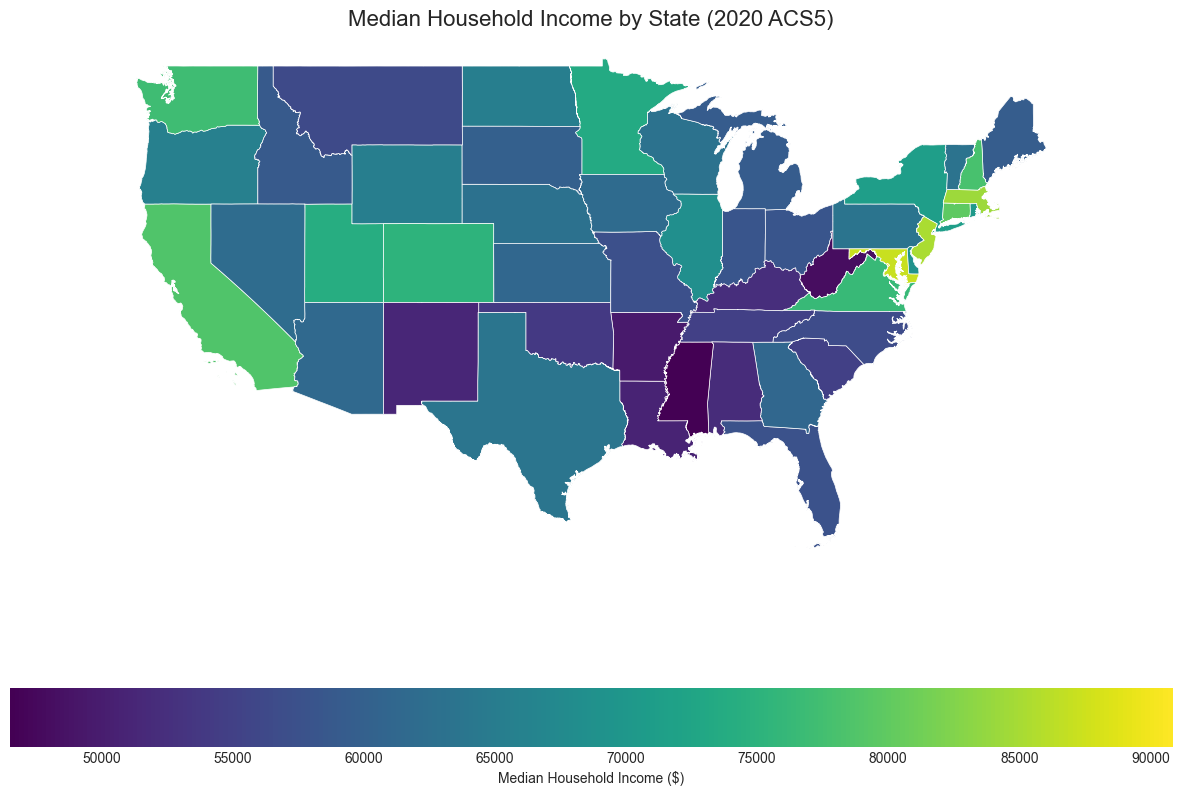

In [8]:
print("🗺️ Visualizing Median Household Income (State Level)...")

# Filter for contiguous US for better plotting
contiguous_us = gdf_state[~gdf_state['STATE'].isin(['02', '15', '72'])].copy()

fig, ax = plt.subplots(figsize=(15, 10))
contiguous_us.plot(
    column='Median_Household_Income',
    cmap='viridis',
    legend=True,
    legend_kwds={'label': "Median Household Income ($)", 'orientation': "horizontal"},
    edgecolor='white',
    linewidth=0.5,
    ax=ax
)
ax.set_title(f"Median Household Income by State ({YEAR} ACS5)", fontsize=16)
ax.axis('off')
plt.show()

---

## 💾 Part 4: Saving Data to DuckDB

We save the data to DuckDB, ensuring the `GEOID` column is preserved.

Tables:
-   `census_acs5_state_2020`
-   `census_acs5_county_2020`

In [ ]:
print("💾 Saving Census Data to DuckDB...")

DB_PATH = os.getenv('PROJECT_DB', '../db/pv_project.ddb')
con = duckdb.connect(DB_PATH)
con.execute("INSTALL spatial; LOAD spatial;")

# 1. Save State Data
state_save = gdf_state.copy()
state_save['geometry'] = state_save['geometry'].apply(lambda x: x.wkt)
con.execute(f"CREATE OR REPLACE TABLE census_acs5_state_{YEAR} AS SELECT * FROM state_save")
print(f"   ✅ Saved 'census_acs5_state_{YEAR}'")

# 2. Save County Data
county_save = gdf_county.copy()
county_save['geometry'] = county_save['geometry'].apply(lambda x: x.wkt)
con.execute(f"CREATE OR REPLACE TABLE census_acs5_county_{YEAR} AS SELECT * FROM county_save")
print(f"   ✅ Saved 'census_acs5_county_{YEAR}'")

# Verify
tables = con.execute("SHOW TABLES").fetchall()
print(f"   Tables in DB: {[t[0] for t in tables]}")

# Check GEOID in saved table
check = con.execute(f"SELECT GEOID FROM census_acs5_county_{YEAR} LIMIT 1").fetchone()
print(f"   Verified GEOID in DB: {check[0]}")

con.close()
print("\n🎉 Notebook complete!")

💾 Saving Census Data to DuckDB...


/var/folders/71/3fjqkxbs6w3frshvsfj30fmm0000gn/T/ipykernel_83556/1409347335.py:9: UserWarning: Geometry column does not contain geometry.
  state_save['geometry'] = state_save['geometry'].apply(lambda x: x.wkt)


   ✅ Saved 'census_acs5_state_2020'


/var/folders/71/3fjqkxbs6w3frshvsfj30fmm0000gn/T/ipykernel_83556/1409347335.py:15: UserWarning: Geometry column does not contain geometry.
  county_save['geometry'] = county_save['geometry'].apply(lambda x: x.wkt)


   ✅ Saved 'census_acs5_county_2020'
   Tables in DB: ['admin_div_geom', 'administrative_divisions', 'census_acs5_county_2020', 'census_acs5_state_2020', 'processed_pv_data']
   Verified GEOID in DB: 01001

🎉 Notebook complete!
